In [1]:
from src.measure_ir import *
import matplotlib.pyplot as plt
import numpy as np
from src.audio_device import AudioDevice
import soundfile as sf
from src.real_time import RealtimeFxLMS

In [2]:
arthur, fs = sf.read('data/arthur_clip_48k.wav')
ad = AudioDevice(fs)

In [3]:
error_ir, _ = measure_ir(ad)

In [4]:
ir_len = 128
panel_to_err_cm = 9
filter_order = 2 * ir_len

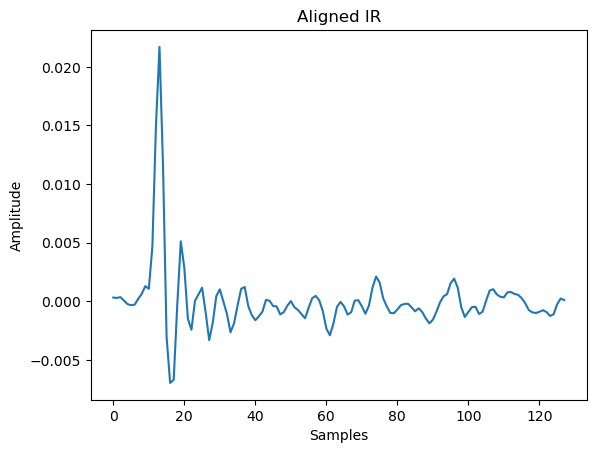

In [5]:
panel_ir = align_ir_by_distance(error_ir, panel_to_err_cm, ir_len)
plt.plot(panel_ir)

plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.title('Aligned IR')
plt.show()

In [49]:
step_sizes = [1e-6, 3e-6, 1e-5]
leaks = [1e-7, 3e-7, 1e-6]
c_gains = [.1, .15]
# block_sizes = [32, 128, 256]
# leak = 3e-7
c_gain = 0.1

In [50]:
arthur_repeated = np.tile(arthur, 25)
arthur.shape, arthur_repeated.shape

((238834,), (5970850,))

In [51]:
rt = RealtimeFxLMS(
        ad,
        source=arthur_repeated,
        ir=panel_ir,
        block_size=64,
        filter_order=filter_order,
    )
error_nc, cancel_nc, *_ = rt.run(source_gain=1.0, cancel_gain=0.0)

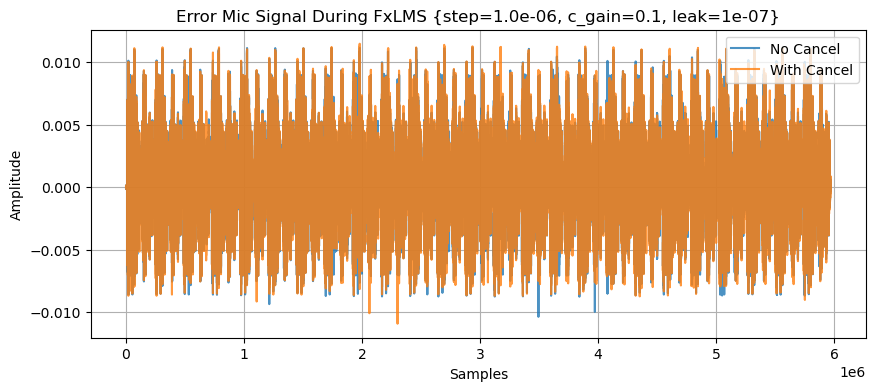

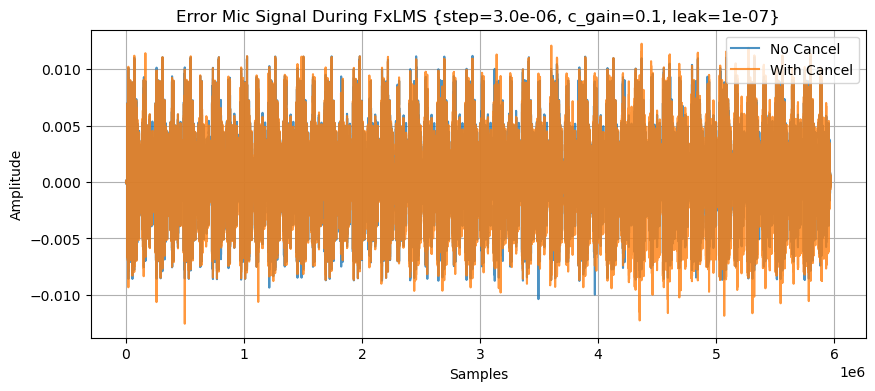

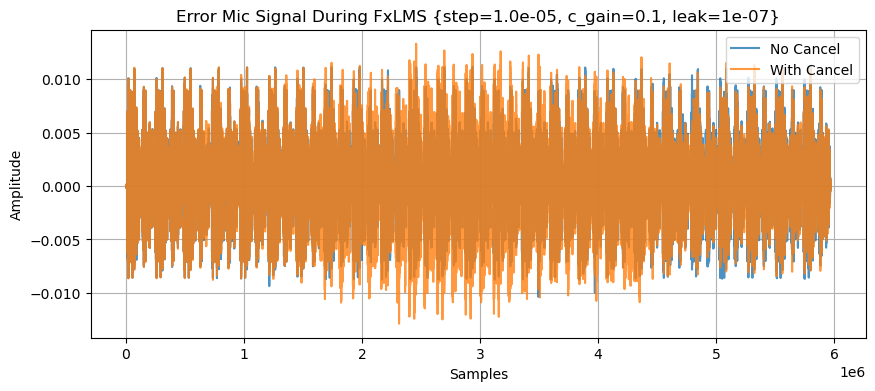

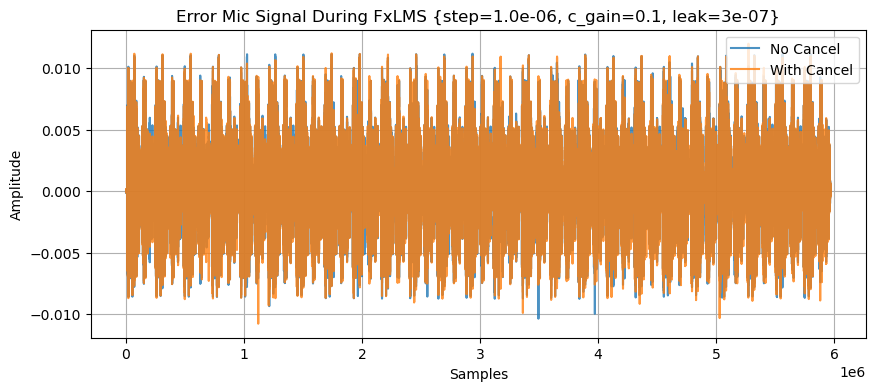

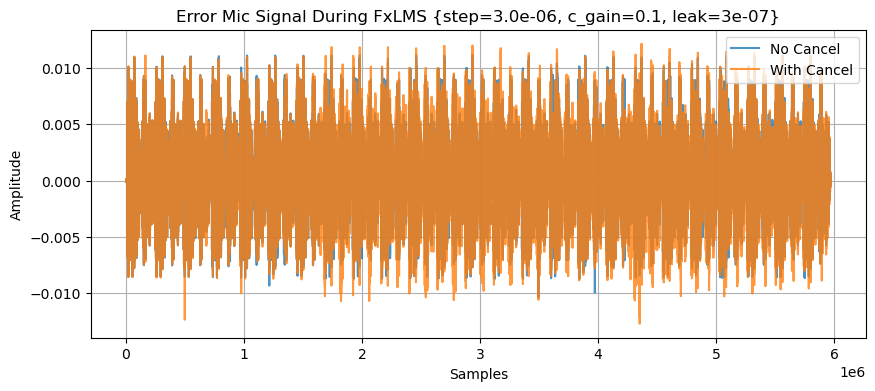

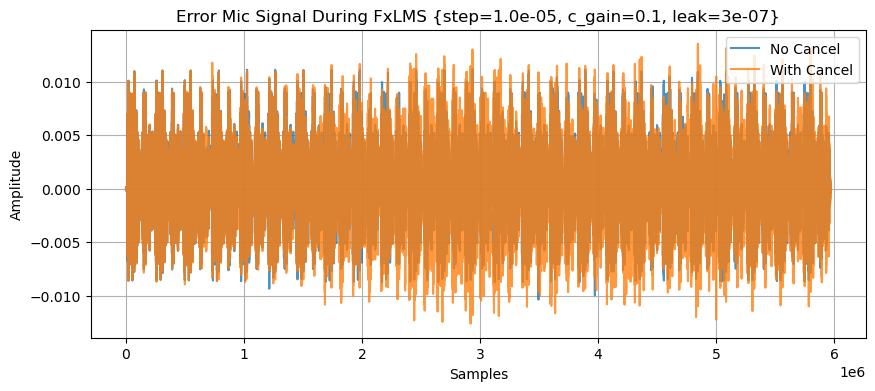

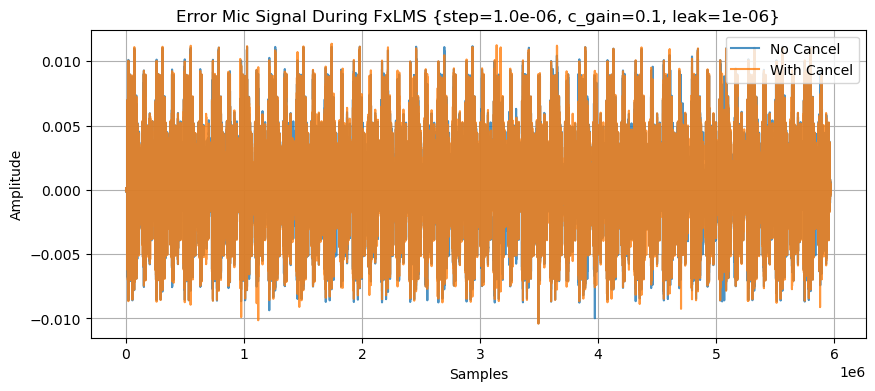

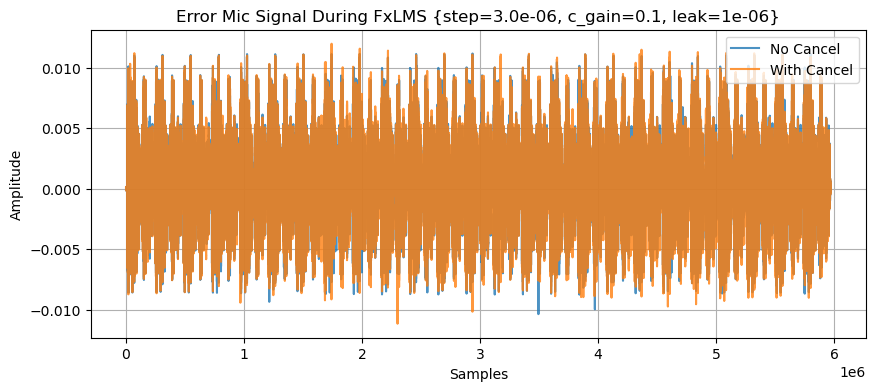

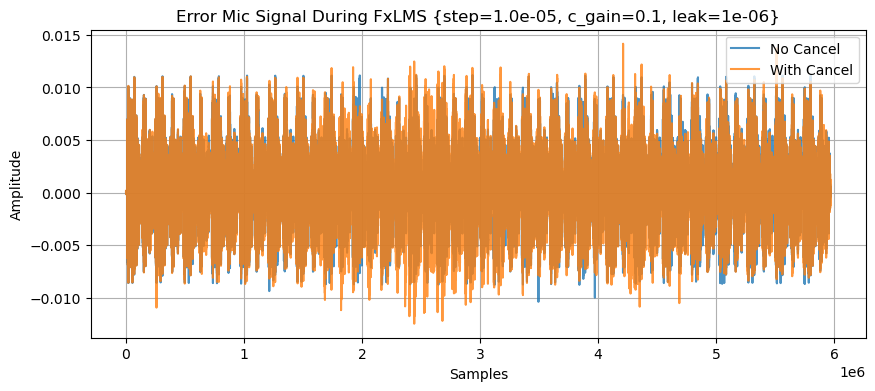

In [53]:
for leak in leaks:
    
    for step in step_sizes:
        rt.reset()
        error, cancel, w_norms, _ = rt.run(
            source_gain=1.0, 
            cancel_gain=.15,
            fx=True,
            nlms=True,
            clean_source=True,
            step_fn=step,
            leak=leak,
            max_norm=1.0
        )
        title_ext = f'{"{"}step={step:1.1e}, c_gain={c_gain}, leak={leak}{"}"}'
        rt.plot_error_mic(error_nc, title_ext=title_ext)
            

In [55]:
arthur_repeated = np.tile(arthur, 50)
arthur.shape, arthur_repeated.shape

((238834,), (11941700,))

In [56]:
rt = RealtimeFxLMS(
    ad,
    source=arthur_repeated,
    ir=panel_ir,
    block_size=64,
    filter_order=filter_order,
)
error_nc, cancel_nc, *_ = rt.run(source_gain=1.0, cancel_gain=0.0)

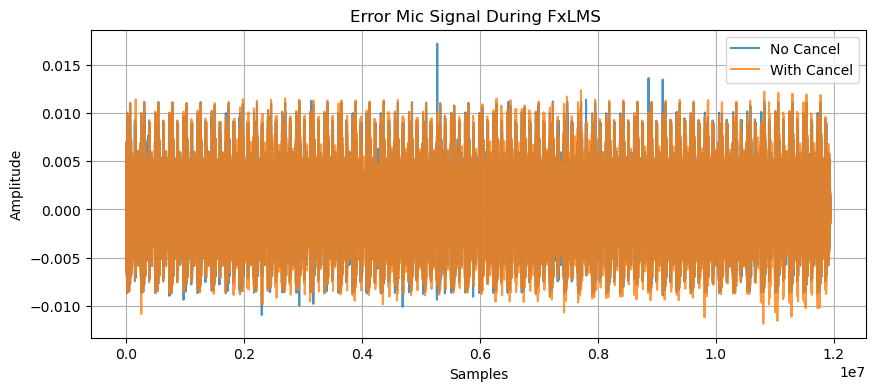

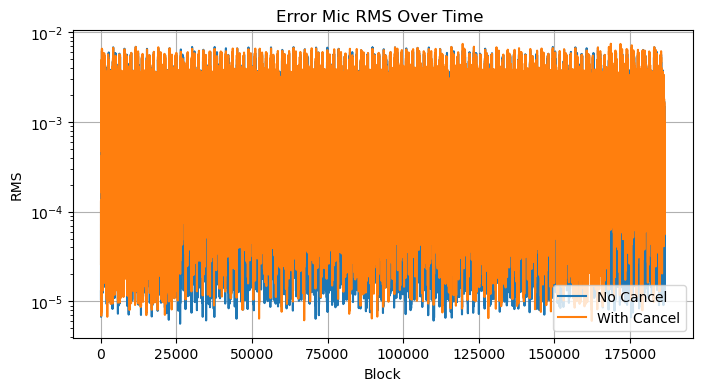

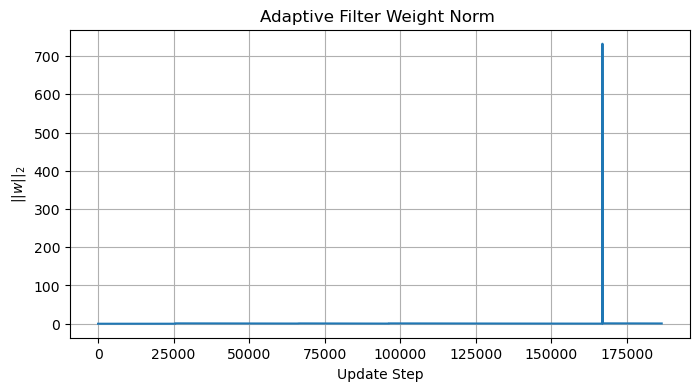

In [59]:
rt.reset()
error, cancel, w_norms, _ = rt.run(
    source_gain=1.0, 
    cancel_gain=.1,
    fx=True,
    nlms=True,
    clean_source=True,
    step_fn=3e-6,
    leak=3e-7,
    max_norm=1.0
)
rt.all_plots(error_nc)

In [9]:
# rt = RealtimeFxLMS(
#     ad,
#     source=arthur,
#     ir=panel_ir,
#     block_size=1024,
#     filter_order=filter_order,
# )
# error_nc, cancel_nc, *_ = rt.run(source_gain=1.0, cancel_gain=0.0)

In [10]:
# rt.reset()
# error_foam, cancel_foam, *_ = rt.run(source_gain=1.0, cancel_gain=0.0)

In [11]:
# plt.plot(error_nc, label='NC With Panel')
# plt.plot(error_foam, label='NC With Foam')

# plt.xlabel('Samples')
# plt.ylabel('Amplitude')
# plt.title('Comparison of Panel Reflections and Other Recorded Waves')
# plt.legend()
# plt.show()